In [ ]:
import pandas as pd
import sklearn
import wfdb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy


In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [ ]:
import numpy as np

# Handle missing values in X
# 'ca' and 'thal' have missing values. Imputing with mode.
for col in ['ca', 'thal']:
    X[col] = X[col].fillna(X[col].mode()[0])

# Map target y to binary (0 vs 1+)
# Original: 0 = absence, 1-4 = presence.
y_binary = (y['num'] > 0).astype(int)

print("Missing values in X after imputation:")
print(X.isnull().sum())
print("\nTarget distribution (Binary):")
print(y_binary.value_counts())

Missing values in X after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64

Target distribution (Binary):
num
0    164
1    139
Name: count, dtype: int64


/tmp/ipykernel_893/2837639540.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna(X[col].mode()[0])


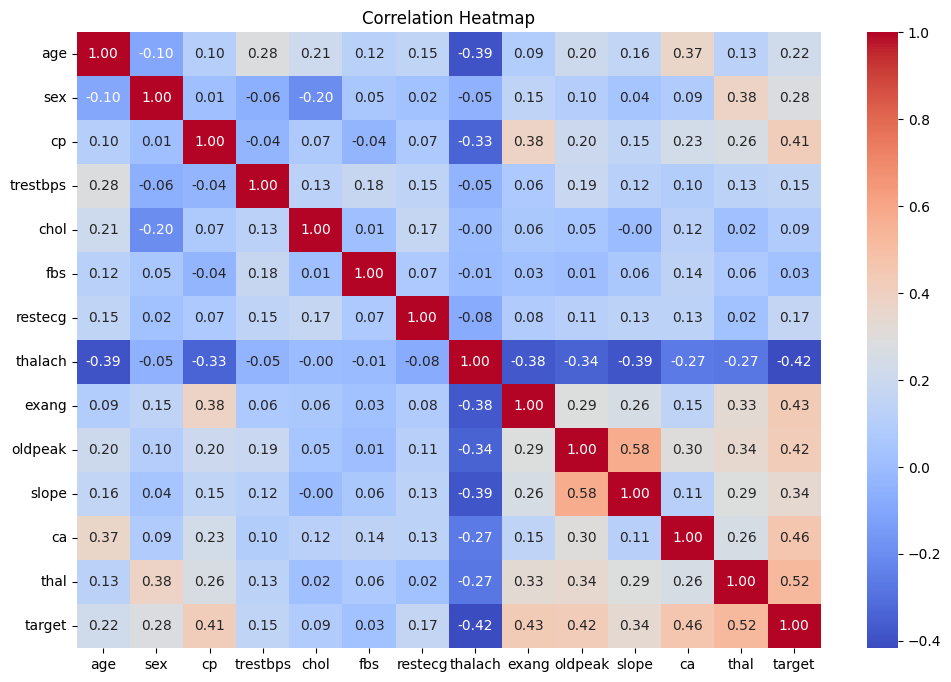

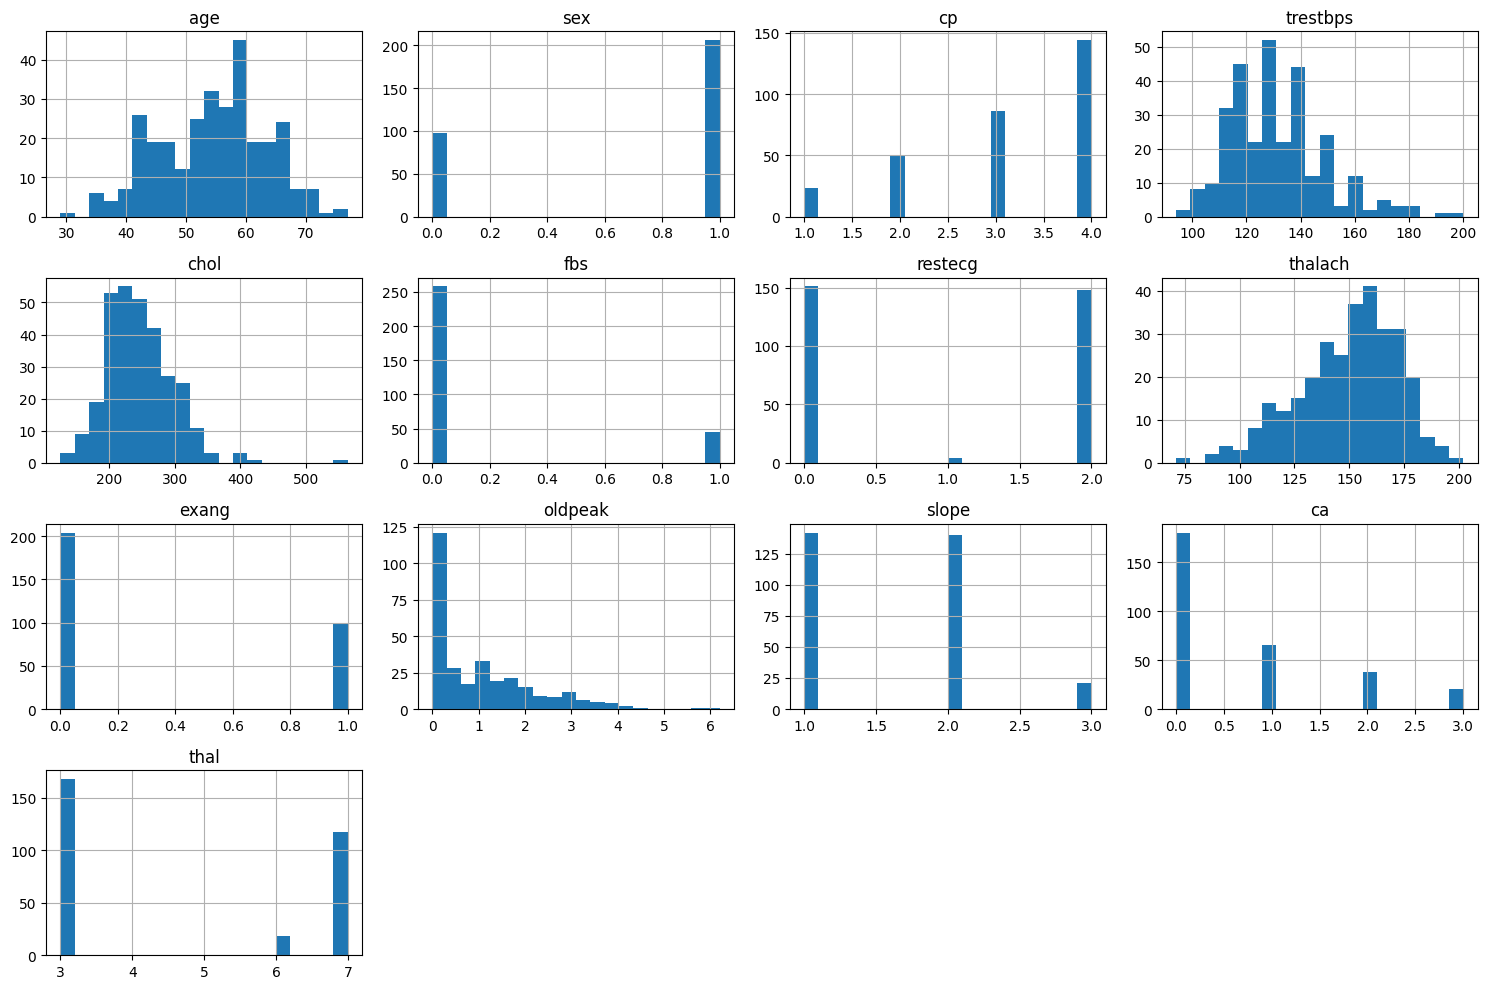

In [ ]:
# Exploratory Data Analysis
plt.figure(figsize=(12, 8))
data_for_corr = X.copy()
data_for_corr['target'] = y_binary

sns.heatmap(data_for_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Feature distributions
X.hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()

Accuracy: 0.8689
ROC AUC: 0.9513


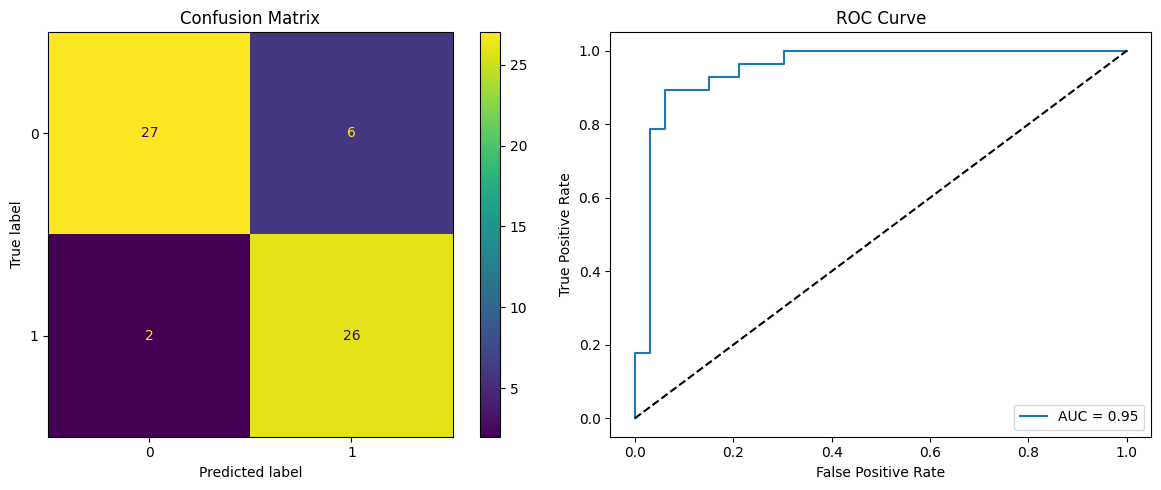

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC: {auc:.4f}")

# Plots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm).plot(ax=ax[0])
ax[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[1].plot(fpr, tpr, label=f'AUC = {auc:.2f}')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Curve')
ax[1].legend()

plt.tight_layout()
plt.show()

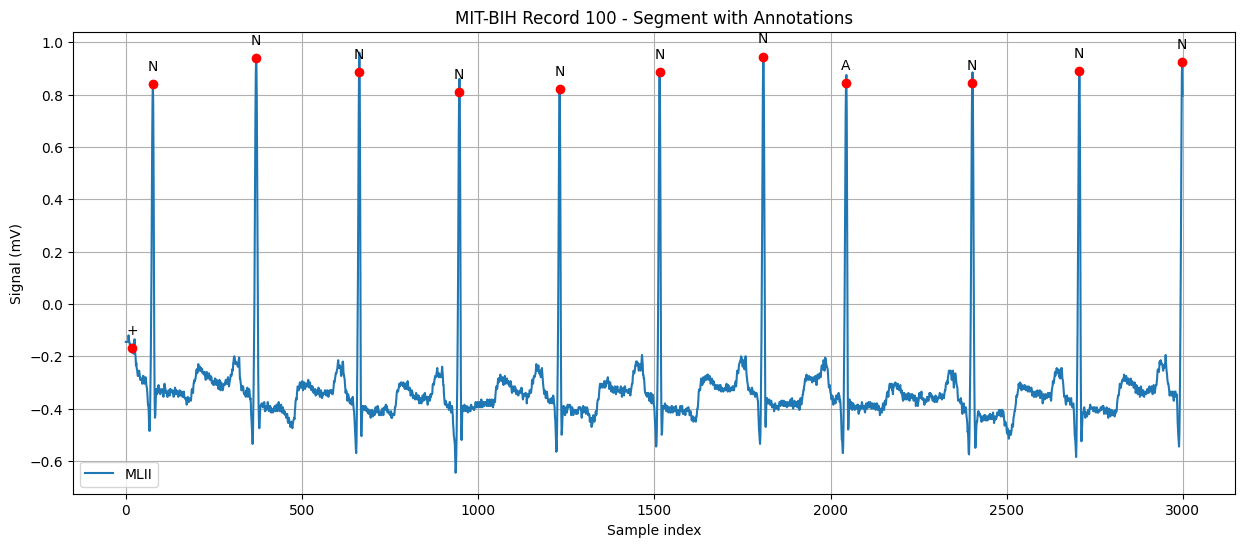

--- Statistics for Record 100 ---
Mean RR interval: 794.32 ms
Std RR interval (SDNN): 50.58 ms
Min RR interval: 163.89 ms
Max RR interval: 1130.56 ms
Estimated Heart Rate: 75.54 BPM


In [ ]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np

# 1. Fetch record '100' from the MIT-BIH Arrhythmia Database
record_name = '100'
record = wfdb.rdrecord(record_name, pn_dir='mitdb')
annotation = wfdb.rdann(record_name, 'atr', pn_dir='mitdb')

# 2. Plot a segment of the ECG waveform with beat annotations
# We'll plot the first 3000 samples (~8 seconds at 360Hz)
start_sample = 0
end_sample = 3000

plt.figure(figsize=(15, 6))
plt.plot(record.p_signal[start_sample:end_sample, 0], label=record.sig_name[0])

# Filter annotations that fall within our window
ann_idx = annotation.sample[(annotation.sample >= start_sample) & (annotation.sample < end_sample)]
ann_sym = [annotation.symbol[i] for i in range(len(annotation.sample)) if start_sample <= annotation.sample[i] < end_sample]

# Plot annotations
plt.plot(ann_idx, record.p_signal[ann_idx, 0], 'ro')
for i, sym in enumerate(ann_sym):
    plt.annotate(sym, (ann_idx[i], record.p_signal[ann_idx[i], 0]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title(f'MIT-BIH Record {record_name} - Segment with Annotations')
plt.xlabel('Sample index')
plt.ylabel(f'Signal ({record.units[0]})')
plt.legend()
plt.grid(True)
plt.show()

# 3. Compute basic heart-rate variability (RR intervals) statistics
# Calculate intervals between beat annotations (in samples)
rr_intervals = np.diff(annotation.sample)
# Convert samples to milliseconds (sampling frequency is 360Hz)
rr_ms = (rr_intervals / record.fs) * 1000

print(f"--- Statistics for Record {record_name} ---")
print(f"Mean RR interval: {np.mean(rr_ms):.2f} ms")
print(f"Std RR interval (SDNN): {np.std(rr_ms):.2f} ms")
print(f"Min RR interval: {np.min(rr_ms):.2f} ms")
print(f"Max RR interval: {np.max(rr_ms):.2f} ms")
print(f"Estimated Heart Rate: {60000 / np.mean(rr_ms):.2f} BPM")

### 4. Textual Data Demonstration (Simple NLP)
We will simulate a clinical note and extract key terms using basic tokenization and word frequency analysis.

In [ ]:
import collections
import re

# Synthetic clinical note
clinical_note = """
Patient presents with acute chest pain and shortness of breath.
History of hypertension and smoking. The chest pain radiates to the left arm.
Patient reports palpitations and occasional dizziness.
Physical exam shows elevated heart rate and mild respiratory distress.
"""

# Basic NLP: Tokenization and cleaning
words = re.findall(r'\w+', clinical_note.lower())
word_counts = collections.Counter(words)

# Identify 'key terms' related to symptoms/conditions
medical_keywords = ['pain', 'chest', 'hypertension', 'smoking', 'heart', 'respiratory', 'palpitations']
extracted_terms = {word: count for word, count in word_counts.items() if word in medical_keywords}

print("Top extracted medical terms:")
for term, count in extracted_terms.items():
    print(f"- {term}: {count}")

print(f"\nFull word count: {len(words)}")

Top extracted medical terms:
- chest: 2
- pain: 2
- hypertension: 1
- smoking: 1
- palpitations: 1
- heart: 1
- respiratory: 1

Full word count: 39


### 5. Image Data Demonstration
Demonstrating how to handle medical images (Resizing and metadata extraction) using a placeholder image.

Original Size: (968, 768) (Width, Height)


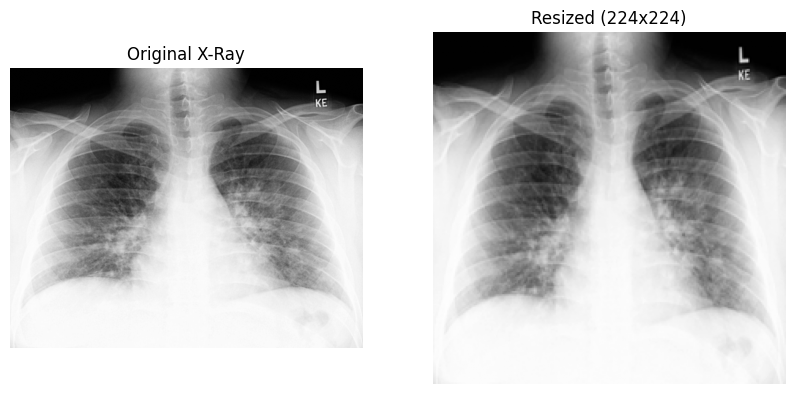

In [ ]:
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

# Using a confirmed stable sample image from scikit-image repo
url = "https://raw.githubusercontent.com/scikit-image/scikit-image/main/skimage/data/chest_xray.exr"
# Using a standard JPG version from a reliable dataset repo to ensure compatibility with PIL
url = "https://raw.githubusercontent.com/ieee8023/covid-chestxray-dataset/master/images/000001-1.jpg"

headers = {'User-Agent': 'Mozilla/5.0'}

try:
    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()
    img = Image.open(BytesIO(response.content)).convert('L')

    # Display original info
    print(f"Original Size: {img.size} (Width, Height)")

    # Preprocessing: Resize for model input (e.g., 224x224)
    img_resized = img.resize((224, 224))

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original X-Ray")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_resized, cmap='gray')
    plt.title("Resized (224x224)")
    plt.axis('off')
    plt.show()
except Exception as e:
    print(f"Error loading image: {e}")

### 6. Integration Discussion

In a real-world clinical setting, these modalities are fused to improve diagnostic accuracy:

*   **Tabular + Signal**: Features derived from the ECG (like HR, SDNN, or R-peak morphology) can be appended as new columns to the Heart Disease tabular dataset. A model could then learn if specific signal anomalies correlate with the `ca` (number of major vessels) or `thal` results.
*   **Tabular + Text**: Natural Language Processing (NLP) on clinical notes can extract symptoms not captured in fixed forms, such as "radiating pain" or "family stress," which act as powerful context for the baseline risk score.
*   **Image + Tabular**: Deep Learning features from Chest X-rays (detecting cardiomegaly/enlarged heart) can serve as a primary indicator for heart failure, augmenting the logistic regression baseline.

**Future Fused Model Architecture:**
A multi-input neural network could take the Tabular vector, a 1D-CNN for ECG signals, and a 2D-CNN for X-ray images, concatenating their latent representations into a final classification layer for Heart Disease presence.